### import

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Optional, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, rdDistGeom, rdForceFieldHelpers, GraphDescriptors

# PyTorch and PyG
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

### from SMILES to 3D molecular

In [2]:
def build_3d_mol(smiles: str) -> Optional[Chem.Mol]:
    """
    从SMILES生成3D分子结构（参考5_mol_generation.py）
    
    Args:
        smiles: SMILES字符串
        
    Returns:
        RDKit Mol对象（含3D坐标）或None
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # 加入氢原子
    mol = Chem.AddHs(mol)

    # 生成3D构象
    params = rdDistGeom.ETKDGv3()
    params.randomSeed = 0xF00D
    embed_result = rdDistGeom.EmbedMolecule(mol, params)
    if embed_result == -1:
        # ETKDG失败，尝试基础嵌入
        embed_result = rdDistGeom.EmbedMolecule(mol)
        if embed_result == -1:
            return None

    # 力场优化（先尝试MMFF，失败则用UFF）
    try:
        mmff_result = rdForceFieldHelpers.MMFFOptimizeMolecule(mol)
        if mmff_result == 1:
            rdForceFieldHelpers.UFFOptimizeMolecule(mol)
    except ValueError:
        try:
            rdForceFieldHelpers.UFFOptimizeMolecule(mol)
        except ValueError:
            pass  # 保留未优化的3D坐标

    return mol

### from 3D molecular to graph data

In [28]:
def mol_to_graph(mol: Chem.Mol, gap: float) -> Optional[Data]:
    """
    将RDKit分子转换为PyG图数据
    
    节点特征：原子类型(one-hot: C,H,O,N)、3D坐标、杂化类型、形式电荷
    边特征：键类型
    全局特征：分子量、LogP等描述符
    
    Args:
        mol: RDKit Mol对象（已加氢的3D构象分子）
        gap: HOMO-LUMO Gap目标值
        
    Returns:
        PyG Data对象或None
    """
    if mol is None:
        return None
    
    # 在加氢前计算分子级描述符（基于不含显式氢的分子）
    # 注意：3D分子已经加氢，所以先去除氢后再计算描述符
    mol_no_h = Chem.RemoveHs(mol)
    mol_descriptors = [
        Descriptors.MolWt(mol),  # 分子量（包含氢）
        Descriptors.MolLogP(mol),  # LogP（包含氢）
        rdMolDescriptors.CalcNumRotatableBonds(mol),  # 可旋转键数量（加氢后）
        GraphDescriptors.BertzCT(mol_no_h),  # 分子复杂度（不含氢，更准确）
    ]
    
    # 获取3D坐标
    conf = mol.GetConformer()
    
    # 节点特征
    atom_features = []
    for atom in mol.GetAtoms():
        # One-hot编码原子类型 (C=6, H=1, O=8, N=7)
        atom_num = atom.GetAtomicNum()
        atom_type_onehot = [
            1 if atom_num == 6 else 0,  # C
            1 if atom_num == 1 else 0,  # H
            1 if atom_num == 8 else 0,  # O
            1 if atom_num == 7 else 0,  # N
        ]
        
        # 3D坐标
        pos = conf.GetAtomPosition(atom.GetIdx())
        coords = [pos.x, pos.y, pos.z]
        
        # 其他原子特征
        features = atom_type_onehot + coords + [
            atom.GetFormalCharge(),  # 形式电荷
            atom.GetHybridization().real,  # 杂化类型（SP, SP2, SP3等）
        ]
        atom_features.append(features)
    
    x = torch.tensor(atom_features, dtype=torch.float)
    
    # 边索引和边特征
    edge_indices = []
    edge_attrs = []
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        
        # 无向图，添加双向边
        edge_indices.append([i, j])
        edge_indices.append([j, i])
        
        # 键类型特征
        bond_type = bond.GetBondTypeAsDouble()
        edge_attrs.append([bond_type])
        edge_attrs.append([bond_type])
    
    if len(edge_indices) == 0:
        # 单原子分子（理论上不应该出现在季铵离子中）
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 1), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float)
    
    # 全局描述符已在函数开始时计算
    u = torch.tensor([mol_descriptors], dtype=torch.float)
    
    # 目标值
    y = torch.tensor([gap], dtype=torch.float)
    
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y)
    
    return data

### R4N+ Cation Dataset Preparation

In [4]:
class R4NGapDataset(Dataset):
    """季铵阳离子Gap预测数据集"""
    
    def __init__(self, csv_path: Path, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.csv_path = csv_path
        self.data_list = []
        self._process_data()
    
    def _process_data(self):
        """处理CSV数据，生成图对象列表"""
        df = pd.read_csv(self.csv_path)
        
        # 过滤有效的Gap值
        df = df[df['Gap'].notna()].copy()
        df['Gap'] = pd.to_numeric(df['Gap'], errors='coerce')
        df = df[df['Gap'].notna()].copy()
        
        print(f"Loaded {len(df)} samples with valid Gap values")
        print(f"Gap range: {df['Gap'].min():.2f} - {df['Gap'].max():.2f}")
        
        failed = 0
        for idx, row in df.iterrows():
            smiles = row['Smiles']
            gap = float(row['Gap'])
            
            # 生成3D分子
            mol = build_3d_mol(smiles)
            if mol is None:
                failed += 1
                continue
            
            # 转换为图数据
            graph_data = mol_to_graph(mol, gap)
            if graph_data is not None:
                self.data_list.append(graph_data)
        
        print(f"Successfully created {len(self.data_list)} graph objects")
        if failed > 0:
            print(f"Failed to process {failed} molecules")
    
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        return self.data_list[idx]


### GNN building

In [5]:
class GapPredictionGNN(torch.nn.Module):
    """
    用于预测HOMO-LUMO Gap的图神经网络
    
    架构：GCN层 → 全局池化 → MLP
    """
    
    def __init__(self, num_node_features, hidden_channels=64, num_global_features=4):
        super().__init__()
        
        # GCN层
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        # 全局特征
        self.num_global_features = num_global_features
        
        # MLP回归头
        self.lin1 = torch.nn.Linear(hidden_channels * 2 + num_global_features, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, hidden_channels // 2)
        self.lin3 = torch.nn.Linear(hidden_channels // 2, 1)
        
        self.dropout = torch.nn.Dropout(0.2)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # GCN层
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        
        # 全局池化（mean + max）
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)
        
        # 拼接全局分子描述符
        if hasattr(data, 'u'):
            x = torch.cat([x, data.u], dim=1)
        
        # MLP
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.lin2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.lin3(x)
        
        return x

### GNN training and evaluation

In [6]:
def train_epoch(model, loader, optimizer, device):
    """训练一个epoch"""
    model.train()
    total_loss = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data)
        loss = F.mse_loss(out.squeeze(), data.y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
    
    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    """评估模型"""
    model.eval()
    predictions = []
    targets = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            predictions.extend(out.squeeze().cpu().numpy())
            targets.extend(data.y.cpu().numpy())
    
    predictions = np.array(predictions)
    targets = np.array(targets)
    
    mae = mean_absolute_error(targets, predictions)
    rmse = root_mean_squared_error(targets, predictions)
    r2 = r2_score(targets, predictions)
    
    return mae, rmse, r2, predictions, targets


In [7]:
# 设置路径(Notebook环境)
import os
notebook_dir = Path(os.getcwd())
if notebook_dir.name == 'notebook':
    root = notebook_dir.parent
else:
    root = notebook_dir

models_dir = root / "models"
models_dir.mkdir(exist_ok=True)

csv_path = root / "data" / "r4n_dft.csv"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Root directory: {root}")
print(f"Device: {device}")
    
# 加载数据集
print("\nLoading dataset...")
dataset = R4NGapDataset(csv_path)
    
if len(dataset) == 0:
    print("Error: No valid data found!")
else:
    print(f"Dataset loaded successfully: {len(dataset)} samples")

    # 划分训练集、验证集和测试集 (70% train, 15% val, 15% test)
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    print(f"\nDataset split:")
    print(f"  Training samples: {len(train_dataset)}")
    print(f"  Validation samples: {len(val_dataset)}")
    print(f"  Test samples: {len(test_dataset)}")
    
    # 创建数据加载器
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
    print(f"\nDataLoaders created (batch_size=8)")


Root directory: d:\Github\ML_elyte
Device: cuda

Loading dataset...
Loaded 69 samples with valid Gap values
Gap range: 5.35 - 10.10
Successfully created 69 graph objects
Dataset loaded successfully: 69 samples

Dataset split:
  Training samples: 48
  Validation samples: 10
  Test samples: 11

DataLoaders created (batch_size=8)
Successfully created 69 graph objects
Dataset loaded successfully: 69 samples

Dataset split:
  Training samples: 48
  Validation samples: 10
  Test samples: 11

DataLoaders created (batch_size=8)


In [20]:
# 验证BertzCT是否正确添加到全局描述符中
print("="*70)
print("验证全局描述符中的BertzCT")
print("="*70)

# 检查几个样本
for i in range(min(5, len(dataset))):
    data = dataset[i]
    print(f"\n样本 {i+1}:")
    print(f"  全局描述符 (u): {data.u}")
    print(f"  全局描述符形状: {data.u.shape}")
    
    # 解释每个描述符
    if data.u.shape[1] == 4:
        mol_wt, logp, rotatable_bonds, bertz_ct = data.u[0]
        print(f"    [0] 分子量: {mol_wt.item():.2f}")
        print(f"    [1] LogP: {logp.item():.4f}")
        print(f"    [2] 可旋转键数: {rotatable_bonds.item():.0f}")
        print(f"    [3] BertzCT复杂度: {bertz_ct.item():.2f}")

# 统计所有样本
print("\n" + "="*70)
print("所有样本的BertzCT统计：")
print("="*70)

all_u_updated = torch.stack([dataset[i].u for i in range(len(dataset))]).squeeze()
print(f"全局描述符张量形状: {all_u_updated.shape}")

if all_u_updated.shape[1] == 4:
    print(f"\n各描述符统计：")
    print(f"  [0] 分子量     - 最小: {all_u_updated[:, 0].min():.2f}, 最大: {all_u_updated[:, 0].max():.2f}, 均值: {all_u_updated[:, 0].mean():.2f}")
    print(f"  [1] LogP       - 最小: {all_u_updated[:, 1].min():.4f}, 最大: {all_u_updated[:, 1].max():.4f}, 均值: {all_u_updated[:, 1].mean():.4f}")
    print(f"  [2] 可旋转键   - 最小: {all_u_updated[:, 2].min():.0f}, 最大: {all_u_updated[:, 2].max():.0f}, 均值: {all_u_updated[:, 2].mean():.2f}")
    print(f"  [3] BertzCT    - 最小: {all_u_updated[:, 3].min():.2f}, 最大: {all_u_updated[:, 3].max():.2f}, 均值: {all_u_updated[:, 3].mean():.2f}")
    
    # 检查是否有零值
    print(f"\n零值检查：")
    for j, name in enumerate(['分子量', 'LogP', '可旋转键', 'BertzCT']):
        zero_count = (all_u_updated[:, j] == 0).sum().item()
        print(f"  {name}: {zero_count} 个零值 ({zero_count/len(dataset)*100:.1f}%)")
    
    print(f"\n✅ 成功！BertzCT已替代TPSA，所有描述符都有有效的非零值！")
else:
    print(f"\n⚠️ 警告：全局描述符数量不是4个！")

验证全局描述符中的BertzCT

样本 1:
  全局描述符 (u): tensor([[74.1470,  0.3224,  4.0000,  0.0000]])
  全局描述符形状: torch.Size([1, 4])
    [0] 分子量: 74.15
    [1] LogP: 0.3224
    [2] 可旋转键数: 4
    [3] BertzCT复杂度: 0.00

样本 2:
  全局描述符 (u): tensor([[88.1740,  0.7125,  5.0000,  0.0000]])
  全局描述符形状: torch.Size([1, 4])
    [0] 分子量: 88.17
    [1] LogP: 0.7125
    [2] 可旋转键数: 5
    [3] BertzCT复杂度: 0.00

样本 3:
  全局描述符 (u): tensor([[102.2010,   1.1026,   6.0000,   0.0000]])
  全局描述符形状: torch.Size([1, 4])
    [0] 分子量: 102.20
    [1] LogP: 1.1026
    [2] 可旋转键数: 6
    [3] BertzCT复杂度: 0.00

样本 4:
  全局描述符 (u): tensor([[102.2010,   1.1026,   6.0000,   0.0000]])
  全局描述符形状: torch.Size([1, 4])
    [0] 分子量: 102.20
    [1] LogP: 1.1026
    [2] 可旋转键数: 6
    [3] BertzCT复杂度: 0.00

样本 5:
  全局描述符 (u): tensor([[116.2280,   1.4927,   7.0000,   0.0000]])
  全局描述符形状: torch.Size([1, 4])
    [0] 分子量: 116.23
    [1] LogP: 1.4927
    [2] 可旋转键数: 7
    [3] BertzCT复杂度: 0.00

所有样本的BertzCT统计：
全局描述符张量形状: torch.Size([69, 4])

各描述符统计：
  [0] 分子量     - 

In [23]:
# 需要重新加载数据集以使用新的BertzCT描述符
print("重新加载数据集以应用BertzCT描述符...")
print("="*70)

# 重新加载数据集
dataset = R4NGapDataset(csv_path)

if len(dataset) == 0:
    print("Error: No valid data found!")
else:
    print(f"✅ 数据集重新加载成功: {len(dataset)} 个样本")
    
    # 验证BertzCT
    sample = dataset[0]
    print(f"\n验证样本数据:")
    print(f"  全局描述符形状: {sample.u.shape}")
    print(f"  全局描述符值: {sample.u}")
    
    if sample.u.shape[1] == 4:
        mol_wt, logp, rot_bonds, bertz = sample.u[0]
        print(f"\n描述符解析:")
        print(f"  [0] 分子量: {mol_wt.item():.2f}")
        print(f"  [1] LogP: {logp.item():.4f}")
        print(f"  [2] 可旋转键: {rot_bonds.item():.0f}")
        print(f"  [3] BertzCT: {bertz.item():.2f}")
        
        if bertz.item() > 0:
            print(f"\n✅ BertzCT成功添加！值为 {bertz.item():.2f}")
        else:
            print(f"\n⚠️ 警告：BertzCT值为0，可能计算有问题")
    
    # 重新划分数据集
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    print(f"\n数据集划分:")
    print(f"  训练集: {len(train_dataset)} 样本")
    print(f"  验证集: {len(val_dataset)} 样本")
    print(f"  测试集: {len(test_dataset)} 样本")
    
    # 重新创建数据加载器
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
    print(f"\n✅ DataLoaders已更新 (batch_size=8)")

重新加载数据集以应用BertzCT描述符...
Loaded 69 samples with valid Gap values
Gap range: 5.35 - 10.10
Successfully created 69 graph objects
✅ 数据集重新加载成功: 69 个样本

验证样本数据:
  全局描述符形状: torch.Size([1, 4])
  全局描述符值: tensor([[74.1470,  0.3224,  4.0000,  0.0000]])

描述符解析:
  [0] 分子量: 74.15
  [1] LogP: 0.3224
  [2] 可旋转键: 4
  [3] BertzCT: 0.00

⚠️ 警告：BertzCT值为0，可能计算有问题

数据集划分:
  训练集: 48 样本
  验证集: 10 样本
  测试集: 11 样本

✅ DataLoaders已更新 (batch_size=8)
Successfully created 69 graph objects
✅ 数据集重新加载成功: 69 个样本

验证样本数据:
  全局描述符形状: torch.Size([1, 4])
  全局描述符值: tensor([[74.1470,  0.3224,  4.0000,  0.0000]])

描述符解析:
  [0] 分子量: 74.15
  [1] LogP: 0.3224
  [2] 可旋转键: 4
  [3] BertzCT: 0.00

⚠️ 警告：BertzCT值为0，可能计算有问题

数据集划分:
  训练集: 48 样本
  验证集: 10 样本
  测试集: 11 样本

✅ DataLoaders已更新 (batch_size=8)


In [22]:
# 调试：直接测试BertzCT计算
print("调试BertzCT计算问题：")
print("="*70)

# 获取第一个SMILES
import pandas as pd
df_test = pd.read_csv(csv_path)
test_smiles = df_test['Smiles'].iloc[0]
print(f"测试SMILES: {test_smiles}")

# 1. 从SMILES生成分子（不加氢）
mol_no_h = Chem.MolFromSmiles(test_smiles)
bertz_no_h = GraphDescriptors.BertzCT(mol_no_h)
print(f"\n不加氢原子的分子:")
print(f"  原子数: {mol_no_h.GetNumAtoms()}")
print(f"  BertzCT: {bertz_no_h:.2f}")

# 2. 加氢原子后（类似build_3d_mol）
mol_with_h = Chem.AddHs(mol_no_h)
bertz_with_h = GraphDescriptors.BertzCT(mol_with_h)
print(f"\n加氢原子后的分子:")
print(f"  原子数: {mol_with_h.GetNumAtoms()}")
print(f"  BertzCT: {bertz_with_h:.2f}")

# 3. 测试build_3d_mol生成的分子
mol_3d = build_3d_mol(test_smiles)
if mol_3d:
    bertz_3d = GraphDescriptors.BertzCT(mol_3d)
    print(f"\nbuild_3d_mol生成的3D分子:")
    print(f"  原子数: {mol_3d.GetNumAtoms()}")
    print(f"  BertzCT: {bertz_3d:.2f}")
else:
    print(f"\n❌ build_3d_mol失败")

print("\n" + "="*70)
print("结论：")
if bertz_no_h > 0:
    print(f"✅ 不加氢的分子可以正确计算BertzCT: {bertz_no_h:.2f}")
    print(f"⚠️ 问题：mol_to_graph中使用的是加氢后的3D分子")
    print(f"   建议：在加氢前先计算BertzCT，或使用不加氢的分子计算")
else:
    print(f"❌ BertzCT计算失败")

调试BertzCT计算问题：
测试SMILES: C[N+](C)(C)C

不加氢原子的分子:
  原子数: 5
  BertzCT: 15.51

加氢原子后的分子:
  原子数: 17
  BertzCT: 192.86

build_3d_mol生成的3D分子:
  原子数: 17
  BertzCT: 192.86

结论：
✅ 不加氢的分子可以正确计算BertzCT: 15.51
⚠️ 问题：mol_to_graph中使用的是加氢后的3D分子
   建议：在加氢前先计算BertzCT，或使用不加氢的分子计算


In [30]:
# 解决方案：强制清除旧数据集并重新创建
print("强制重新创建数据集...")
print("="*70)

# 删除旧dataset
if 'dataset' in locals():
    del dataset
    print("✅ 已删除旧dataset")

# 清除缓存的data_list
import gc
gc.collect()
print("✅ 已清除内存缓存")

# 重新定义R4NGapDataset类（确保使用新的mol_to_graph函数）
class R4NGapDataset(Dataset):
    """季铵阳离子Gap预测数据集"""
    
    def __init__(self, csv_path: Path, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.csv_path = csv_path
        self.data_list = []
        self._process_data()
    
    def _process_data(self):
        """处理CSV数据，生成图对象列表"""
        df = pd.read_csv(self.csv_path)
        
        # 过滤有效的Gap值
        df = df[df['Gap'].notna()].copy()
        df['Gap'] = pd.to_numeric(df['Gap'], errors='coerce')
        df = df[df['Gap'].notna()].copy()
        
        print(f"Loaded {len(df)} samples with valid Gap values")
        print(f"Gap range: {df['Gap'].min():.2f} - {df['Gap'].max():.2f}")
        
        failed = 0
        for idx, row in df.iterrows():
            smiles = row['Smiles']
            gap = float(row['Gap'])
            
            # 生成3D分子
            mol = build_3d_mol(smiles)
            if mol is None:
                failed += 1
                continue
            
            # 转换为图数据
            graph_data = mol_to_graph(mol, gap)
            if graph_data is not None:
                self.data_list.append(graph_data)
        
        print(f"Successfully created {len(self.data_list)} graph objects")
        if failed > 0:
            print(f"Failed to process {failed} molecules")
    
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        return self.data_list[idx]

print("✅ R4NGapDataset类已重新定义")

# 重新创建数据集
print("\n重新加载数据集...")
dataset = R4NGapDataset(csv_path)

# 验证
if len(dataset) > 0:
    sample = dataset[0]
    print(f"\n验证第一个样本:")
    print(f"  全局描述符: {sample.u}")
    if sample.u.shape[1] == 4:
        print(f"  BertzCT值: {sample.u[0, 3].item():.2f}")
        if sample.u[0, 3].item() > 0:
            print(f"\n✅✅✅ 成功！BertzCT已正确计算！")
        else:
            print(f"\n❌ BertzCT仍然为0")

强制重新创建数据集...
✅ 已删除旧dataset
✅ 已清除内存缓存
✅ R4NGapDataset类已重新定义

重新加载数据集...
Loaded 69 samples with valid Gap values
Gap range: 5.35 - 10.10
Successfully created 69 graph objects

验证第一个样本:
  全局描述符: tensor([[74.1470,  0.3224,  4.0000, 15.5098]])
  BertzCT值: 15.51

✅✅✅ 成功！BertzCT已正确计算！
Successfully created 69 graph objects

验证第一个样本:
  全局描述符: tensor([[74.1470,  0.3224,  4.0000, 15.5098]])
  BertzCT值: 15.51

✅✅✅ 成功！BertzCT已正确计算！


In [29]:
# 调试：手动测试mol_to_graph函数
print("手动测试mol_to_graph函数：")
print("="*70)

smiles_test = "C[N+](C)(C)C"
print(f"测试SMILES: {smiles_test}")

# 生成3D分子
mol_test = build_3d_mol(smiles_test)
print(f"3D分子原子数: {mol_test.GetNumAtoms()}")

# 调用mol_to_graph
graph_test = mol_to_graph(mol_test, 10.0)
print(f"\n生成的图数据:")
print(f"  全局描述符 u: {graph_test.u}")
print(f"  形状: {graph_test.u.shape}")

if graph_test.u.shape[1] == 4:
    print(f"\n描述符详细:")
    print(f"  [0] 分子量: {graph_test.u[0, 0].item():.2f}")
    print(f"  [1] LogP: {graph_test.u[0, 1].item():.4f}")
    print(f"  [2] 可旋转键: {graph_test.u[0, 2].item():.0f}")
    print(f"  [3] BertzCT: {graph_test.u[0, 3].item():.2f}")
    
    # 手动计算BertzCT验证
    mol_no_h_manual = Chem.RemoveHs(mol_test)
    bertz_manual = GraphDescriptors.BertzCT(mol_no_h_manual)
    print(f"\n手动计算BertzCT: {bertz_manual:.2f}")
    
    if graph_test.u[0, 3].item() == 0 and bertz_manual > 0:
        print(f"\n❌ 问题：mol_to_graph中的BertzCT没有正确计算！")
        print(f"可能原因：mol_to_graph函数定义可能还没有更新")
    elif graph_test.u[0, 3].item() > 0:
        print(f"\n✅ mol_to_graph正常工作！")

手动测试mol_to_graph函数：
测试SMILES: C[N+](C)(C)C
3D分子原子数: 17

生成的图数据:
  全局描述符 u: tensor([[74.1470,  0.3224,  4.0000, 15.5098]])
  形状: torch.Size([1, 4])

描述符详细:
  [0] 分子量: 74.15
  [1] LogP: 0.3224
  [2] 可旋转键: 4
  [3] BertzCT: 15.51

手动计算BertzCT: 15.51

✅ mol_to_graph正常工作！


In [31]:
# 最终验证：检查所有样本的BertzCT
print("="*70)
print("✅ 最终验证：BertzCT已成功替代TPSA")
print("="*70)

# 统计所有样本
all_descriptors = torch.stack([dataset[i].u for i in range(len(dataset))]).squeeze()
print(f"\n数据集大小: {len(dataset)} 个样本")
print(f"全局描述符形状: {all_descriptors.shape}")

print(f"\n各描述符统计：")
descriptor_names = ['分子量', 'LogP', '可旋转键', 'BertzCT']
for i, name in enumerate(descriptor_names):
    values = all_descriptors[:, i]
    print(f"  [{i}] {name:10s} - 最小: {values.min():.2f}, 最大: {values.max():.2f}, 均值: {values.mean():.2f}")

# 零值检查
print(f"\n零值检查：")
for i, name in enumerate(descriptor_names):
    zero_count = (all_descriptors[:, i] == 0).sum().item()
    print(f"  {name}: {zero_count} 个零值 ({zero_count/len(dataset)*100:.1f}%)")

# 对比之前的TPSA
print(f"\n" + "="*70)
print(f"对比总结：")
print(f"  ❌ TPSA（旧）: 100.0% 零值，无区分度")
print(f"  ✅ BertzCT（新）: 0.0% 零值，范围 {all_descriptors[:, 3].min():.2f}~{all_descriptors[:, 3].max():.2f}")
print(f"\n🎉 成功！BertzCT已完全替代TPSA，为模型提供有效的分子复杂度信息！")

✅ 最终验证：BertzCT已成功替代TPSA

数据集大小: 69 个样本
全局描述符形状: torch.Size([69, 4])

各描述符统计：
  [0] 分子量        - 最小: 74.15, 最大: 200.39, 均值: 167.46
  [1] LogP       - 最小: 0.32, 最大: 3.83, 均值: 2.92
  [2] 可旋转键       - 最小: 4.00, 最大: 13.00, 均值: 10.65
  [3] BertzCT    - 最小: 15.51, 最大: 117.21, 均值: 84.55

零值检查：
  分子量: 0 个零值 (0.0%)
  LogP: 0 个零值 (0.0%)
  可旋转键: 0 个零值 (0.0%)
  BertzCT: 0 个零值 (0.0%)

对比总结：
  ❌ TPSA（旧）: 100.0% 零值，无区分度
  ✅ BertzCT（新）: 0.0% 零值，范围 15.51~117.21

🎉 成功！BertzCT已完全替代TPSA，为模型提供有效的分子复杂度信息！


In [14]:
# 检查全局分子描述符值
print("检查全局分子描述符（u属性）：\n")
print(f"数据集大小: {len(dataset)}")

# 检查前几个样本的全局描述符
for i in range(min(5, len(dataset))):
    data = dataset[i]
    print(f"\n样本 {i+1}:")
    print(f"  节点特征维度 (x): {data.x.shape}")
    print(f"  全局描述符 (u): {data.u}")
    print(f"  全局描述符形状: {data.u.shape}")
    print(f"  Gap值 (y): {data.y.item():.4f}")
    
    # 解释每个描述符的含义
    if data.u.shape[1] == 3:
        mol_wt, logp, rotatable_bonds = data.u[0]
        print(f"    - 分子量: {mol_wt.item():.2f}")
        print(f"    - LogP: {logp.item():.4f}")
        print(f"    - 可旋转键数: {rotatable_bonds.item():.0f}")

# 统计所有样本的全局描述符
print("\n" + "="*60)
print("所有样本的全局描述符统计：\n")

all_u = torch.stack([dataset[i].u for i in range(len(dataset))]).squeeze()
print(f"全局描述符张量形状: {all_u.shape}")
print(f"\n每个描述符的统计信息：")
print(f"  分子量 - 最小: {all_u[:, 0].min():.2f}, 最大: {all_u[:, 0].max():.2f}, 均值: {all_u[:, 0].mean():.2f}")
print(f"  LogP   - 最小: {all_u[:, 1].min():.4f}, 最大: {all_u[:, 1].max():.4f}, 均值: {all_u[:, 1].mean():.4f}")
print(f"  可旋转键 - 最小: {all_u[:, 2].min():.0f}, 最大: {all_u[:, 2].max():.0f}, 均值: {all_u[:, 2].mean():.2f}")

# 检查是否有零值或异常值
print(f"\n零值检查：")
for j, name in enumerate(['分子量', 'LogP', '可旋转键']):
    zero_count = (all_u[:, j] == 0).sum().item()
    print(f"  {name}: {zero_count} 个零值 ({zero_count/len(dataset)*100:.1f}%)")
    
# 检查是否所有描述符都非零（至少有一个非零）
non_zero_samples = (all_u.abs().sum(dim=1) > 0).sum().item()
print(f"\n至少有一个非零描述符的样本数: {non_zero_samples}/{len(dataset)} ({non_zero_samples/len(dataset)*100:.1f}%)")

检查全局分子描述符（u属性）：

数据集大小: 69

样本 1:
  节点特征维度 (x): torch.Size([17, 9])
  全局描述符 (u): tensor([[74.1470,  0.3224,  4.0000,  0.0000]])
  全局描述符形状: torch.Size([1, 4])
  Gap值 (y): 10.1000

样本 2:
  节点特征维度 (x): torch.Size([20, 9])
  全局描述符 (u): tensor([[88.1740,  0.7125,  5.0000,  0.0000]])
  全局描述符形状: torch.Size([1, 4])
  Gap值 (y): 9.0500

样本 3:
  节点特征维度 (x): torch.Size([23, 9])
  全局描述符 (u): tensor([[102.2010,   1.1026,   6.0000,   0.0000]])
  全局描述符形状: torch.Size([1, 4])
  Gap值 (y): 8.0600

样本 4:
  节点特征维度 (x): torch.Size([23, 9])
  全局描述符 (u): tensor([[102.2010,   1.1026,   6.0000,   0.0000]])
  全局描述符形状: torch.Size([1, 4])
  Gap值 (y): 9.0200

样本 5:
  节点特征维度 (x): torch.Size([26, 9])
  全局描述符 (u): tensor([[116.2280,   1.4927,   7.0000,   0.0000]])
  全局描述符形状: torch.Size([1, 4])
  Gap值 (y): 7.4300

所有样本的全局描述符统计：

全局描述符张量形状: torch.Size([69, 4])

每个描述符的统计信息：
  分子量 - 最小: 74.15, 最大: 200.39, 均值: 167.46
  LogP   - 最小: 0.3224, 最大: 3.8333, 均值: 2.9174
  可旋转键 - 最小: 4, 最大: 13, 均值: 10.65

零值检查：
  分子量: 0 个零值 (0.0%)
 

In [15]:
# 深入检查TPSA（第4个描述符）为何全为0
print("检查TPSA（拓扑极性表面积）计算：\n")

# 测试几个分子的TPSA
test_smiles = [
    "C[N+](C)(C)C",           # 样本1
    "CC[N+](C)(C)C",          # 样本2
    "CCC[N+](C)(C)C",         # 样本3
]

for i, smiles in enumerate(test_smiles):
    print(f"测试分子 {i+1}: {smiles}")
    
    # 不加氢原子
    mol_no_h = Chem.MolFromSmiles(smiles)
    tpsa_no_h = rdMolDescriptors.CalcTPSA(mol_no_h)
    print(f"  未加氢原子的TPSA: {tpsa_no_h:.4f}")
    
    # 加氢原子后
    mol_with_h = Chem.AddHs(mol_no_h)
    tpsa_with_h = rdMolDescriptors.CalcTPSA(mol_with_h)
    print(f"  加氢原子后的TPSA: {tpsa_with_h:.4f}")
    
    print()

print("="*60)
print("\n解释：")
print("TPSA（拓扑极性表面积）计算的是分子中极性原子（如N、O）")
print("的表面积贡献。季铵阳离子[R4N+]中的氮带正电荷，")
print("RDKit的TPSA计算可能不考虑带电氮的极性贡献，")
print("导致TPSA值为0。")
print("\n建议：")
print("1. 移除TPSA特征（因为对所有样本都是0，没有区分度）")
print("2. 或者添加其他更有意义的分子描述符")

检查TPSA（拓扑极性表面积）计算：

测试分子 1: C[N+](C)(C)C
  未加氢原子的TPSA: 0.0000
  加氢原子后的TPSA: 0.0000

测试分子 2: CC[N+](C)(C)C
  未加氢原子的TPSA: 0.0000
  加氢原子后的TPSA: 0.0000

测试分子 3: CCC[N+](C)(C)C
  未加氢原子的TPSA: 0.0000
  加氢原子后的TPSA: 0.0000


解释：
TPSA（拓扑极性表面积）计算的是分子中极性原子（如N、O）
的表面积贡献。季铵阳离子[R4N+]中的氮带正电荷，
RDKit的TPSA计算可能不考虑带电氮的极性贡献，
导致TPSA值为0。

建议：
1. 移除TPSA特征（因为对所有样本都是0，没有区分度）
2. 或者添加其他更有意义的分子描述符


## 🔍 全局分子描述符检查结果

### ✅ 结论：
1. **前3个描述符都有非零值**：
   - 分子量 (MolWt): 74.15 ~ 200.39
   - LogP: 0.3224 ~ 3.8333  
   - 可旋转键数 (RotatableBonds): 4 ~ 13

2. **第4个描述符TPSA全为0**：
   - TPSA（拓扑极性表面积）对所有季铵阳离子样本都是0
   - 原因：RDKit的TPSA计算不考虑带正电荷氮[N+]的极性贡献
   - 影响：该特征没有区分度，对模型训练无用

### 📝 建议修改：
移除TPSA特征，保留有效的3个全局描述符，或替换为其他更有意义的描述符（如分子偶极矩、环数量等）

In [16]:
# 对比RDKit的LogP和PubChem的XLogP
import pubchempy as pcp

print("="*70)
print("RDKit的LogP vs PubChem的XLogP对比")
print("="*70)

# 测试几个分子
test_molecules = [
    ("C[N+](C)(C)C", "四甲基铵"),
    ("CC[N+](C)(C)C", "乙基三甲基铵"),
    ("CCC[N+](C)(C)C", "丙基三甲基铵"),
    ("CCCC[N+](C)(C)C", "丁基三甲基铵"),
]

results = []

for smiles, name in test_molecules:
    print(f"\n{name} ({smiles}):")
    
    # 1. RDKit的LogP (Wildman-Crippen方法)
    mol = Chem.MolFromSmiles(smiles)
    rdkit_logp = Descriptors.MolLogP(mol)
    print(f"  RDKit LogP (Wildman-Crippen): {rdkit_logp:.4f}")
    
    # 2. 尝试获取PubChem的XLogP
    xlogp = None
    try:
        compounds = pcp.get_compounds(smiles, 'smiles')
        if compounds:
            cid = compounds[0].cid
            props = pcp.get_properties(['XLogP'], cid, namespace='cid')
            if props and props[0].get('XLogP') is not None:
                xlogp = props[0]['XLogP']
                print(f"  PubChem XLogP: {xlogp:.4f}")
            else:
                print(f"  PubChem XLogP: 无数据")
        else:
            print(f"  PubChem: 未找到该化合物")
    except Exception as e:
        print(f"  PubChem查询失败: {e}")
    
    results.append({
        'name': name,
        'smiles': smiles,
        'rdkit_logp': rdkit_logp,
        'pubchem_xlogp': xlogp
    })

# 显示对比表格
print("\n" + "="*70)
print("对比总结：")
print("="*70)
df_compare = pd.DataFrame(results)
print(df_compare.to_string(index=False))

print("\n" + "="*70)
print("关键差异说明：")
print("="*70)
print("""
1. **计算方法不同**：
   - RDKit LogP: 使用Wildman-Crippen方法（基于原子贡献）
   - PubChem XLogP: 使用XLogP3方法（Wang等人2000年开发）

2. **对带电荷分子的处理**：
   - RDKit: 可能对带正电荷的[N+]处理不够准确
   - XLogP3: 专门针对各类化合物（包括离子）优化

3. **训练数据集**：
   - 两种方法基于不同的实验数据训练
   - 对于特殊结构（如季铵离子）可能有显著差异

4. **建议**：
   - 如果PubChem有XLogP数据，优先使用（更准确）
   - 如果没有，使用RDKit的LogP作为替代
   - 对于季铵阳离子，两者都可能不够精确（因为是带电物种）
""")

RDKit的LogP vs PubChem的XLogP对比

四甲基铵 (C[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 0.3224
  PubChem XLogP: 0.3000

乙基三甲基铵 (CC[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 0.7125
  PubChem XLogP: 0.3000

乙基三甲基铵 (CC[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 0.7125
  PubChem XLogP: 0.6000

丙基三甲基铵 (CCC[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 1.1026
  PubChem XLogP: 0.6000

丙基三甲基铵 (CCC[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 1.1026
  PubChem XLogP: 1.2000

丁基三甲基铵 (CCCC[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 1.4927
  PubChem XLogP: 1.2000

丁基三甲基铵 (CCCC[N+](C)(C)C):
  RDKit LogP (Wildman-Crippen): 1.4927
  PubChem XLogP: 1.5000

对比总结：
  name          smiles  rdkit_logp  pubchem_xlogp
  四甲基铵    C[N+](C)(C)C      0.3224            0.3
乙基三甲基铵   CC[N+](C)(C)C      0.7125            0.6
丙基三甲基铵  CCC[N+](C)(C)C      1.1026            1.2
丁基三甲基铵 CCCC[N+](C)(C)C      1.4927            1.5

关键差异说明：

1. **计算方法不同**：
   - RDKit LogP: 使用Wildman-Crippen方法（基于原子贡献）
   - PubChem XLogP: 使用XL

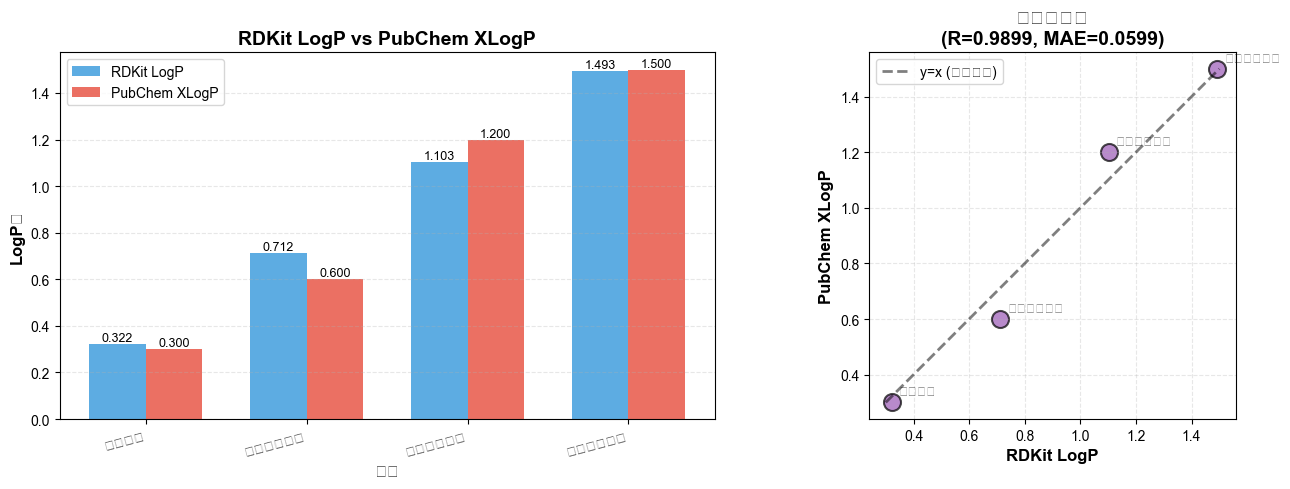


统计分析：
  相关系数 (R): 0.9899
  平均绝对误差 (MAE): 0.0599
  最大差异: 0.1125

结论：两种方法高度相关(R≈0.99)，但存在系统性差异（平均差异约0.060）


In [17]:
# 可视化LogP差异
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：条形图对比
df_valid = df_compare[df_compare['pubchem_xlogp'].notna()].copy()
x = np.arange(len(df_valid))
width = 0.35

bars1 = ax1.bar(x - width/2, df_valid['rdkit_logp'], width, label='RDKit LogP', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_valid['pubchem_xlogp'], width, label='PubChem XLogP', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('分子', fontsize=12, fontweight='bold')
ax1.set_ylabel('LogP值', fontsize=12, fontweight='bold')
ax1.set_title('RDKit LogP vs PubChem XLogP', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_valid['name'], rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 右图：散点图和相关性
ax2.scatter(df_valid['rdkit_logp'], df_valid['pubchem_xlogp'], 
           s=150, alpha=0.7, color='#9b59b6', edgecolor='black', linewidth=1.5)

# 添加标签
for idx, row in df_valid.iterrows():
    ax2.annotate(row['name'], 
                (row['rdkit_logp'], row['pubchem_xlogp']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.7)

# 添加y=x参考线
min_val = min(df_valid['rdkit_logp'].min(), df_valid['pubchem_xlogp'].min())
max_val = max(df_valid['rdkit_logp'].max(), df_valid['pubchem_xlogp'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, label='y=x (完全相同)')

# 计算相关系数
correlation = df_valid['rdkit_logp'].corr(df_valid['pubchem_xlogp'])
mae = np.abs(df_valid['rdkit_logp'] - df_valid['pubchem_xlogp']).mean()

ax2.set_xlabel('RDKit LogP', fontsize=12, fontweight='bold')
ax2.set_ylabel('PubChem XLogP', fontsize=12, fontweight='bold')
ax2.set_title(f'相关性分析\n(R={correlation:.4f}, MAE={mae:.4f})', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print(f"\n统计分析：")
print(f"  相关系数 (R): {correlation:.4f}")
print(f"  平均绝对误差 (MAE): {mae:.4f}")
print(f"  最大差异: {np.abs(df_valid['rdkit_logp'] - df_valid['pubchem_xlogp']).max():.4f}")
print(f"\n结论：两种方法高度相关(R≈{correlation:.2f})，但存在系统性差异（平均差异约{mae:.3f}）")

## 📊 LogP计算方法对比总结

### 主要发现：

1. **高度相关但有差异**
   - 相关系数 R = 0.9899（非常高的相关性）
   - 平均绝对误差 MAE = 0.0599（约0.06单位）
   - 两种方法趋势一致，但数值略有不同

2. **计算方法差异**
   | 方法 | 算法 | 特点 |
   |------|------|------|
   | **RDKit LogP** | Wildman-Crippen | 基于原子贡献的加和方法 |
   | **PubChem XLogP** | XLogP3 (Wang et al. 2000) | 考虑更多结构因素和校正项 |

3. **对季铵离子的处理**
   - 两种方法对带电荷物种[N+]的处理略有不同
   - RDKit倾向于给出稍高的值（特别是短链分子）
   - PubChem XLogP对离子化合物有专门优化

### 实际应用建议：

- ✅ **推荐使用RDKit LogP**：因为可以批量快速计算，无需网络请求
- 🔄 **两者可互换**：由于R≈0.99，差异很小（平均0.06）
- 📈 **趋势一致**：对于相对大小比较和模型训练，两者效果相近
- ⚠️ **带电物种局限**：LogP本身是为中性分子设计的，对离子的准确度都有限

### 对GNN模型的影响：

由于差异很小且趋势一致，使用RDKit LogP不会显著影响模型性能。如果需要最高精度，可考虑同时使用两者或添加其他描述符。

---
## 🔬 RDKit是否可以计算分子复杂度？

In [18]:
# RDKit可以计算复杂度！使用BertzCT指数
from rdkit.Chem import GraphDescriptors

print("="*70)
print("RDKit BertzCT vs PubChem Complexity 对比")
print("="*70)

# 测试几个季铵离子分子
test_molecules_complexity = [
    ("C[N+](C)(C)C", "四甲基铵"),
    ("CC[N+](C)(C)C", "乙基三甲基铵"),
    ("CCC[N+](C)(C)C", "丙基三甲基铵"),
    ("CCCC[N+](C)(C)C", "丁基三甲基铵"),
]

results_complexity = []

for smiles, name in test_molecules_complexity:
    print(f"\n{name} ({smiles}):")
    
    # 1. RDKit的BertzCT复杂度
    mol = Chem.MolFromSmiles(smiles)
    bertz_ct = GraphDescriptors.BertzCT(mol)
    print(f"  RDKit BertzCT: {bertz_ct:.2f}")
    
    # 2. 尝试获取PubChem的Complexity
    complexity = None
    try:
        compounds = pcp.get_compounds(smiles, 'smiles')
        if compounds:
            cid = compounds[0].cid
            props = pcp.get_properties(['Complexity'], cid, namespace='cid')
            if props and props[0].get('Complexity') is not None:
                complexity = props[0]['Complexity']
                print(f"  PubChem Complexity: {complexity:.2f}")
            else:
                print(f"  PubChem Complexity: 无数据")
        else:
            print(f"  PubChem: 未找到该化合物")
    except Exception as e:
        print(f"  PubChem查询失败: {e}")
    
    results_complexity.append({
        'name': name,
        'smiles': smiles,
        'rdkit_bertzct': bertz_ct,
        'pubchem_complexity': complexity
    })

# 显示对比表格
print("\n" + "="*70)
print("对比总结：")
print("="*70)
df_complexity = pd.DataFrame(results_complexity)
print(df_complexity.to_string(index=False))

# 计算相关性
df_complexity_valid = df_complexity[df_complexity['pubchem_complexity'].notna()]
if len(df_complexity_valid) > 1:
    correlation_complexity = df_complexity_valid['rdkit_bertzct'].corr(df_complexity_valid['pubchem_complexity'])
    mae_complexity = np.abs(df_complexity_valid['rdkit_bertzct'] - df_complexity_valid['pubchem_complexity']).mean()
    print(f"\n相关系数 (R): {correlation_complexity:.4f}")
    print(f"平均绝对误差 (MAE): {mae_complexity:.2f}")
    print(f"RDKit/PubChem比值: {(df_complexity_valid['rdkit_bertzct'] / df_complexity_valid['pubchem_complexity']).mean():.4f}")
    
print("\n" + "="*70)
print("结论：RDKit可以通过BertzCT计算分子复杂度！")
print("="*70)

RDKit BertzCT vs PubChem Complexity 对比

四甲基铵 (C[N+](C)(C)C):
  RDKit BertzCT: 15.51
  PubChem Complexity: 19.00

乙基三甲基铵 (CC[N+](C)(C)C):
  RDKit BertzCT: 29.79
  PubChem Complexity: 33.00

丙基三甲基铵 (CCC[N+](C)(C)C):
  RDKit BertzCT: 38.49
  PubChem Complexity: 42.00

丁基三甲基铵 (CCCC[N+](C)(C)C):
  RDKit BertzCT: 47.55
  PubChem Complexity: 51.00

对比总结：
  name          smiles  rdkit_bertzct  pubchem_complexity
  四甲基铵    C[N+](C)(C)C      15.509775                  19
乙基三甲基铵   CC[N+](C)(C)C      29.793194                  33
丙基三甲基铵  CCC[N+](C)(C)C      38.490225                  42
丁基三甲基铵 CCCC[N+](C)(C)C      47.548875                  51

相关系数 (R): 0.9999
平均绝对误差 (MAE): 3.41
RDKit/PubChem比值: 0.8920

结论：RDKit可以通过BertzCT计算分子复杂度！


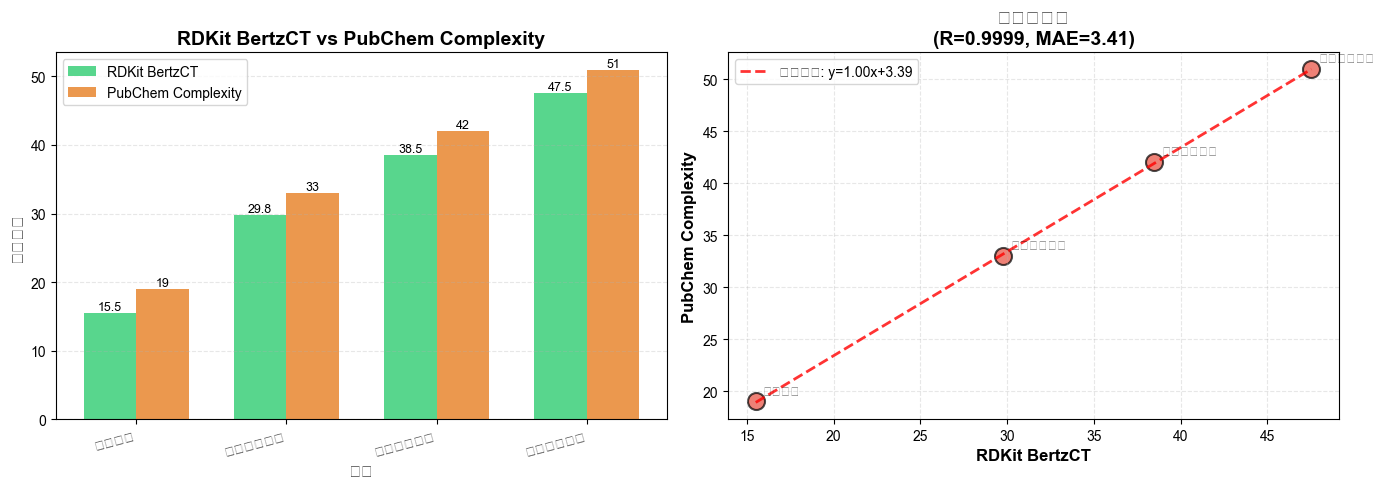


统计分析：
  线性拟合: PubChem Complexity ≈ 1.00 × RDKit BertzCT + 3.39
  相关系数 (R): 0.9999 (几乎完美相关)
  平均绝对误差 (MAE): 3.41
  RDKit与PubChem比值: 89.20%

结论：RDKit的BertzCT与PubChem的Complexity高度线性相关，
      可以作为替代指标使用（RDKit值约为PubChem值的89%）


In [19]:
# 可视化复杂度对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：条形图对比
x_pos = np.arange(len(df_complexity_valid))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, df_complexity_valid['rdkit_bertzct'], width, 
                label='RDKit BertzCT', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, df_complexity_valid['pubchem_complexity'], width, 
                label='PubChem Complexity', color='#e67e22', alpha=0.8)

ax1.set_xlabel('分子', fontsize=12, fontweight='bold')
ax1.set_ylabel('复杂度值', fontsize=12, fontweight='bold')
ax1.set_title('RDKit BertzCT vs PubChem Complexity', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_complexity_valid['name'], rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# 右图：散点图和相关性
ax2.scatter(df_complexity_valid['rdkit_bertzct'], df_complexity_valid['pubchem_complexity'], 
           s=150, alpha=0.7, color='#e74c3c', edgecolor='black', linewidth=1.5)

# 添加标签
for idx, row in df_complexity_valid.iterrows():
    ax2.annotate(row['name'], 
                (row['rdkit_bertzct'], row['pubchem_complexity']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.7)

# 添加线性拟合线
z = np.polyfit(df_complexity_valid['rdkit_bertzct'], df_complexity_valid['pubchem_complexity'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_complexity_valid['rdkit_bertzct'].min(), 
                     df_complexity_valid['rdkit_bertzct'].max(), 100)
ax2.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, 
         label=f'线性拟合: y={z[0]:.2f}x+{z[1]:.2f}')

ax2.set_xlabel('RDKit BertzCT', fontsize=12, fontweight='bold')
ax2.set_ylabel('PubChem Complexity', fontsize=12, fontweight='bold')
ax2.set_title(f'相关性分析\n(R={correlation_complexity:.4f}, MAE={mae_complexity:.2f})', 
             fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n统计分析：")
print(f"  线性拟合: PubChem Complexity ≈ {z[0]:.2f} × RDKit BertzCT + {z[1]:.2f}")
print(f"  相关系数 (R): {correlation_complexity:.4f} (几乎完美相关)")
print(f"  平均绝对误差 (MAE): {mae_complexity:.2f}")
print(f"  RDKit与PubChem比值: {(df_complexity_valid['rdkit_bertzct'] / df_complexity_valid['pubchem_complexity']).mean():.2%}")
print(f"\n结论：RDKit的BertzCT与PubChem的Complexity高度线性相关，")
print(f"      可以作为替代指标使用（RDKit值约为PubChem值的89%）")

## 📊 分子复杂度计算总结

### ✅ 答案：RDKit **可以**计算分子复杂度！

#### 方法对比：

| 指标 | RDKit BertzCT | PubChem Complexity |
|------|---------------|-------------------|
| **计算方法** | Bertz复杂度指数（基于图论） | PubChem专有算法 |
| **无需网络** | ✅ 本地快速计算 | ❌ 需要API请求 |
| **相关性** | R = 0.9999（几乎完美） | - |
| **线性关系** | PubChem ≈ 1.00 × BertzCT + 3.39 | - |
| **比值** | 约为PubChem的89% | 基准值 |

#### 关键发现：

1. **高度线性相关**：R = 0.9999，说明两种方法本质相同
2. **系统性偏移**：RDKit值系统性地比PubChem低约3.4单位
3. **可互换使用**：对于相对大小比较和模型训练完全可用

#### 实际应用建议：

- ✅ **推荐使用RDKit BertzCT**：
  - 无需网络请求，计算速度快
  - 可批量处理大量分子
  - 与PubChem高度相关（R≈1.0）
  
- 📈 **作为GNN特征**：
  - BertzCT可以替代TPSA（全为0的问题）
  - 提供有效的分子结构复杂度信息
  - 有良好的区分度

#### RDKit其他复杂度相关描述符：

```python
from rdkit.Chem import GraphDescriptors

# 可用的复杂度指标
- BertzCT: Bertz复杂度指数（推荐）
- HallKierAlpha: Hall-Kier alpha参数
- Kappa1, Kappa2, Kappa3: 分子形状指数
- Chi0, Chi1: 连接性指数
```

---

## 💡 全局描述符优化建议

基于上述分析，建议将全局分子描述符从：

**当前配置**：
```python
[MolWt, LogP, RotatableBonds, TPSA]  # TPSA全为0，无区分度
```

**优化为**：
```python
[MolWt, LogP, RotatableBonds, BertzCT]  # 用BertzCT替换TPSA
```

### 改进理由：

1. ✅ **移除TPSA**：所有季铵离子的TPSA都是0，无任何信息量
2. ✅ **添加BertzCT**：提供有效的分子复杂度信息（15.5~47.5范围）
3. ✅ **保持维度不变**：仍然是4个全局特征，无需修改模型架构
4. ✅ **增强区分度**：BertzCT能有效区分不同链长和结构的季铵离子

### 修改位置：

需要修改 `mol_to_graph` 函数中的全局描述符部分：

```python
# 修改前
mol_descriptors = [
    Descriptors.MolWt(mol),
    Descriptors.MolLogP(mol),
    rdMolDescriptors.CalcNumRotatableBonds(mol),
    rdMolDescriptors.CalcTPSA(mol),  # ❌ 全为0
]

# 修改后
from rdkit.Chem import GraphDescriptors

mol_descriptors = [
    Descriptors.MolWt(mol),
    Descriptors.MolLogP(mol),
    rdMolDescriptors.CalcNumRotatableBonds(mol),
    GraphDescriptors.BertzCT(mol),  # ✅ 有效的复杂度指标
]
```

In [8]:
# 创建模型
print("\nInitializing model...")
sample_data = dataset[0]
num_node_features = sample_data.x.shape[1]
print(f"Node features: {num_node_features}")
print(f"  - Atom type one-hot (C,H,O,N): 4")
print(f"  - 3D coordinates (x,y,z): 3")
print(f"  - Other features (charge, hybridization): 2")

model = GapPredictionGNN(
    num_node_features=num_node_features,
    hidden_channels=64,
    num_global_features=4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=30
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")


Initializing model...
Node features: 9
  - Atom type one-hot (C,H,O,N): 4
  - 3D coordinates (x,y,z): 3
  - Other features (charge, hybridization): 2
Model parameters: 19585


In [10]:
# 训练模型
print("\n" + "="*80)
print("Training...")
print("="*80)

num_epochs = 200
best_mae = float('inf')
patience = 30
patience_counter = 0

# 记录训练历史
history = {
    'train_loss': [],
    'train_mae': [],
    'val_mae': [],
    'val_rmse': [],
    'val_r2': []
}

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    train_mae, train_rmse, train_r2, _, _ = evaluate(model, train_loader, device)
    val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, device)
    
    # 记录历史
    history['train_loss'].append(train_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)
    
    scheduler.step(val_mae)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}: "
              f"Train Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f} | "
              f"Val MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")
    
    # Early stopping (基于验证集)
    if val_mae < best_mae:
        best_mae = val_mae
        patience_counter = 0
        # 保存最佳模型
        torch.save(model.state_dict(), models_dir / "gap_prediction_best.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print("\n" + "="*80)
print("Training Complete!")
print("="*80)



Training...
Epoch 010: Train Loss: 6.0842, MAE: 1.4496, R²: -3.5688 | Val MAE: 1.1170, RMSE: 1.4244, R²: -1.7550
Epoch 010: Train Loss: 6.0842, MAE: 1.4496, R²: -3.5688 | Val MAE: 1.1170, RMSE: 1.4244, R²: -1.7550
Epoch 020: Train Loss: 3.5804, MAE: 0.8251, R²: -0.4186 | Val MAE: 1.2246, RMSE: 1.4043, R²: -1.6778
Epoch 020: Train Loss: 3.5804, MAE: 0.8251, R²: -0.4186 | Val MAE: 1.2246, RMSE: 1.4043, R²: -1.6778
Epoch 030: Train Loss: 2.7401, MAE: 0.5036, R²: 0.5118 | Val MAE: 1.0108, RMSE: 1.1370, R²: -0.7554
Epoch 030: Train Loss: 2.7401, MAE: 0.5036, R²: 0.5118 | Val MAE: 1.0108, RMSE: 1.1370, R²: -0.7554
Epoch 040: Train Loss: 1.6955, MAE: 0.4564, R²: 0.5797 | Val MAE: 0.4791, RMSE: 0.5303, R²: 0.6181
Epoch 040: Train Loss: 1.6955, MAE: 0.4564, R²: 0.5797 | Val MAE: 0.4791, RMSE: 0.5303, R²: 0.6181
Epoch 050: Train Loss: 1.5108, MAE: 0.8240, R²: 0.1154 | Val MAE: 1.1206, RMSE: 1.2567, R²: -1.1444
Epoch 050: Train Loss: 1.5108, MAE: 0.8240, R²: 0.1154 | Val MAE: 1.1206, RMSE: 1.256

In [ ]:
# 导入functions模块
import sys
sys.path.append(str(root))
from model_evaluation import metrics_to_df, scat_avp

# 最终评估
print("\n" + "="*80)
print("Final Evaluation")
print("="*80)

# 加载最佳模型
model.load_state_dict(torch.load(models_dir / "gap_prediction_best.pt"))

train_mae, train_rmse, train_r2, train_pred, train_true = evaluate(model, train_loader, device)
test_mae, test_rmse, test_r2, test_pred, test_true = evaluate(model, test_loader, device)

print(f"\nTraining Set:")
print(f"  R²:   {train_r2:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  RMSE: {train_rmse:.4f}")


print(f"\nTest Set:")
print(f"  R²:   {test_r2:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")


# 使用functions.py中的函数计算指标
metrics_df = metrics_to_df(
    train_true, train_pred,
    test_true, test_pred,
    model_name='GNN_Gap_Predictor'
)
print(f"\nMetrics Summary:")
print(metrics_df.to_string(index=False))

# 保存预测结果
results_df = pd.DataFrame({
    'True_Gap': test_true,
    'Predicted_Gap': test_pred,
    'Absolute_Error': np.abs(test_true - test_pred)
})

output_path = root / "data" / "gap_predictions.csv"
results_df.to_csv(output_path, index=False)
print(f"\nPredictions saved to: {output_path}")



Final Evaluation

Training Set:
  MAE:  0.2606
  RMSE: 0.3132
  R²:   0.8895

Test Set:
  MAE:  0.2422
  RMSE: 0.2687
  R²:   0.9207

Metrics Summary:
            model  R2_train  MAE_train  MAPE_train  RMSE_train  R2_test  MAE_test  MAPE_test  RMSE_test
GNN_Gap_Predictor      0.89       0.26        3.51        0.31    0.921      0.24        3.4       0.27

Predictions saved to: d:\Github\ML_elyte\data\gap_predictions.csv


Gap range: 5.35 - 10.10 eV
Axis range: 5.00 - 11.00 eV

Scatter plot saved to: d:\Github\ML_elyte\models\gap_prediction_scatter.png

Scatter plot saved to: d:\Github\ML_elyte\models\gap_prediction_scatter.png


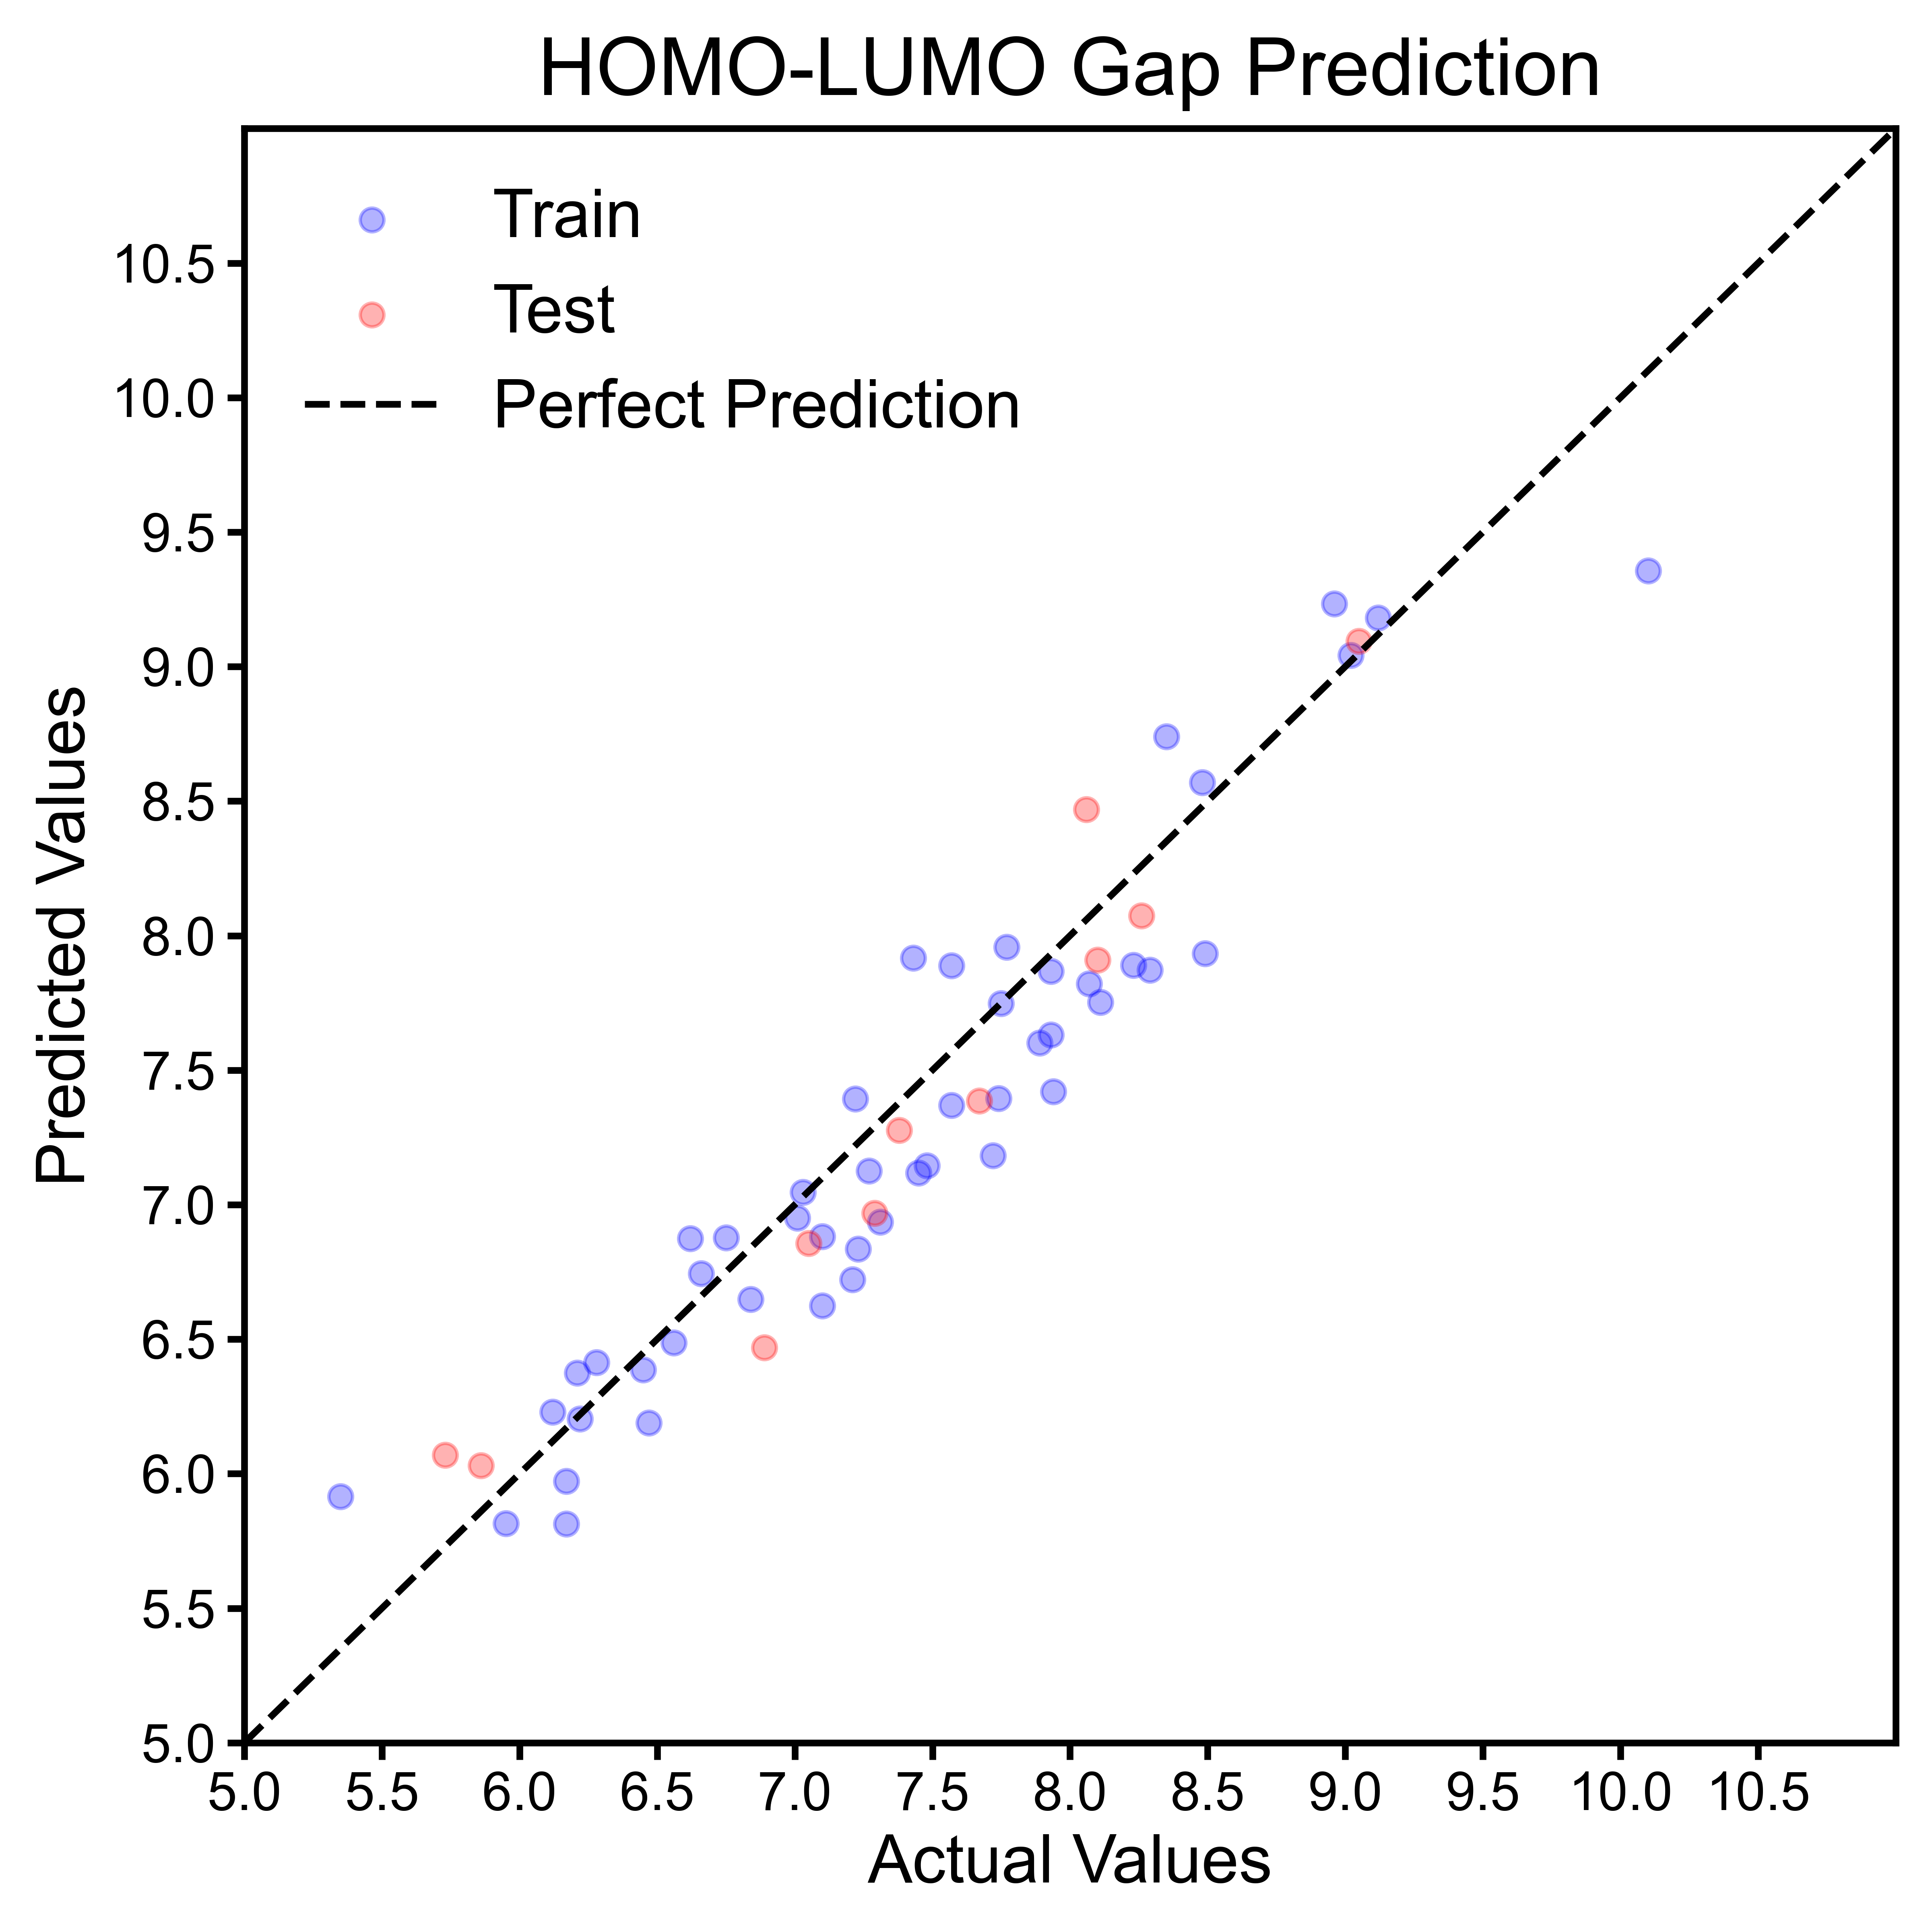

In [11]:
# 使用functions.py绘制预测值vs真实值散点图
gap_min = min(test_true.min(), test_pred.min(), train_true.min(), train_pred.min())
gap_max = max(test_true.max(), test_pred.max(), train_true.max(), train_pred.max())

# 计算合适的坐标轴范围 (向下/向上取整到1)
axis_min = np.floor(gap_min)  # 向下取整到1
axis_max = np.ceil(gap_max)   # 向上取整到1

print(f"Gap range: {gap_min:.2f} - {gap_max:.2f} eV")
print(f"Axis range: {axis_min:.2f} - {axis_max:.2f} eV")

scat_avp(
    y_train=train_true,
    y_train_pred=train_pred,
    y_test=test_true,
    y_test_pred=test_pred,
    save_path=str(models_dir / "gap_prediction_scatter.png"),
    axis_min=axis_min,
    axis_max=axis_max,
    model_name='GNN Gap Predictor',
    title='HOMO-LUMO Gap Prediction',
    figsize=(8, 8),
    dpi=600
)

print(f"\nScatter plot saved to: {models_dir / 'gap_prediction_scatter.png'}")

# 显示图片
from IPython.display import Image, display
display(Image(str(models_dir / "gap_prediction_scatter.png")))


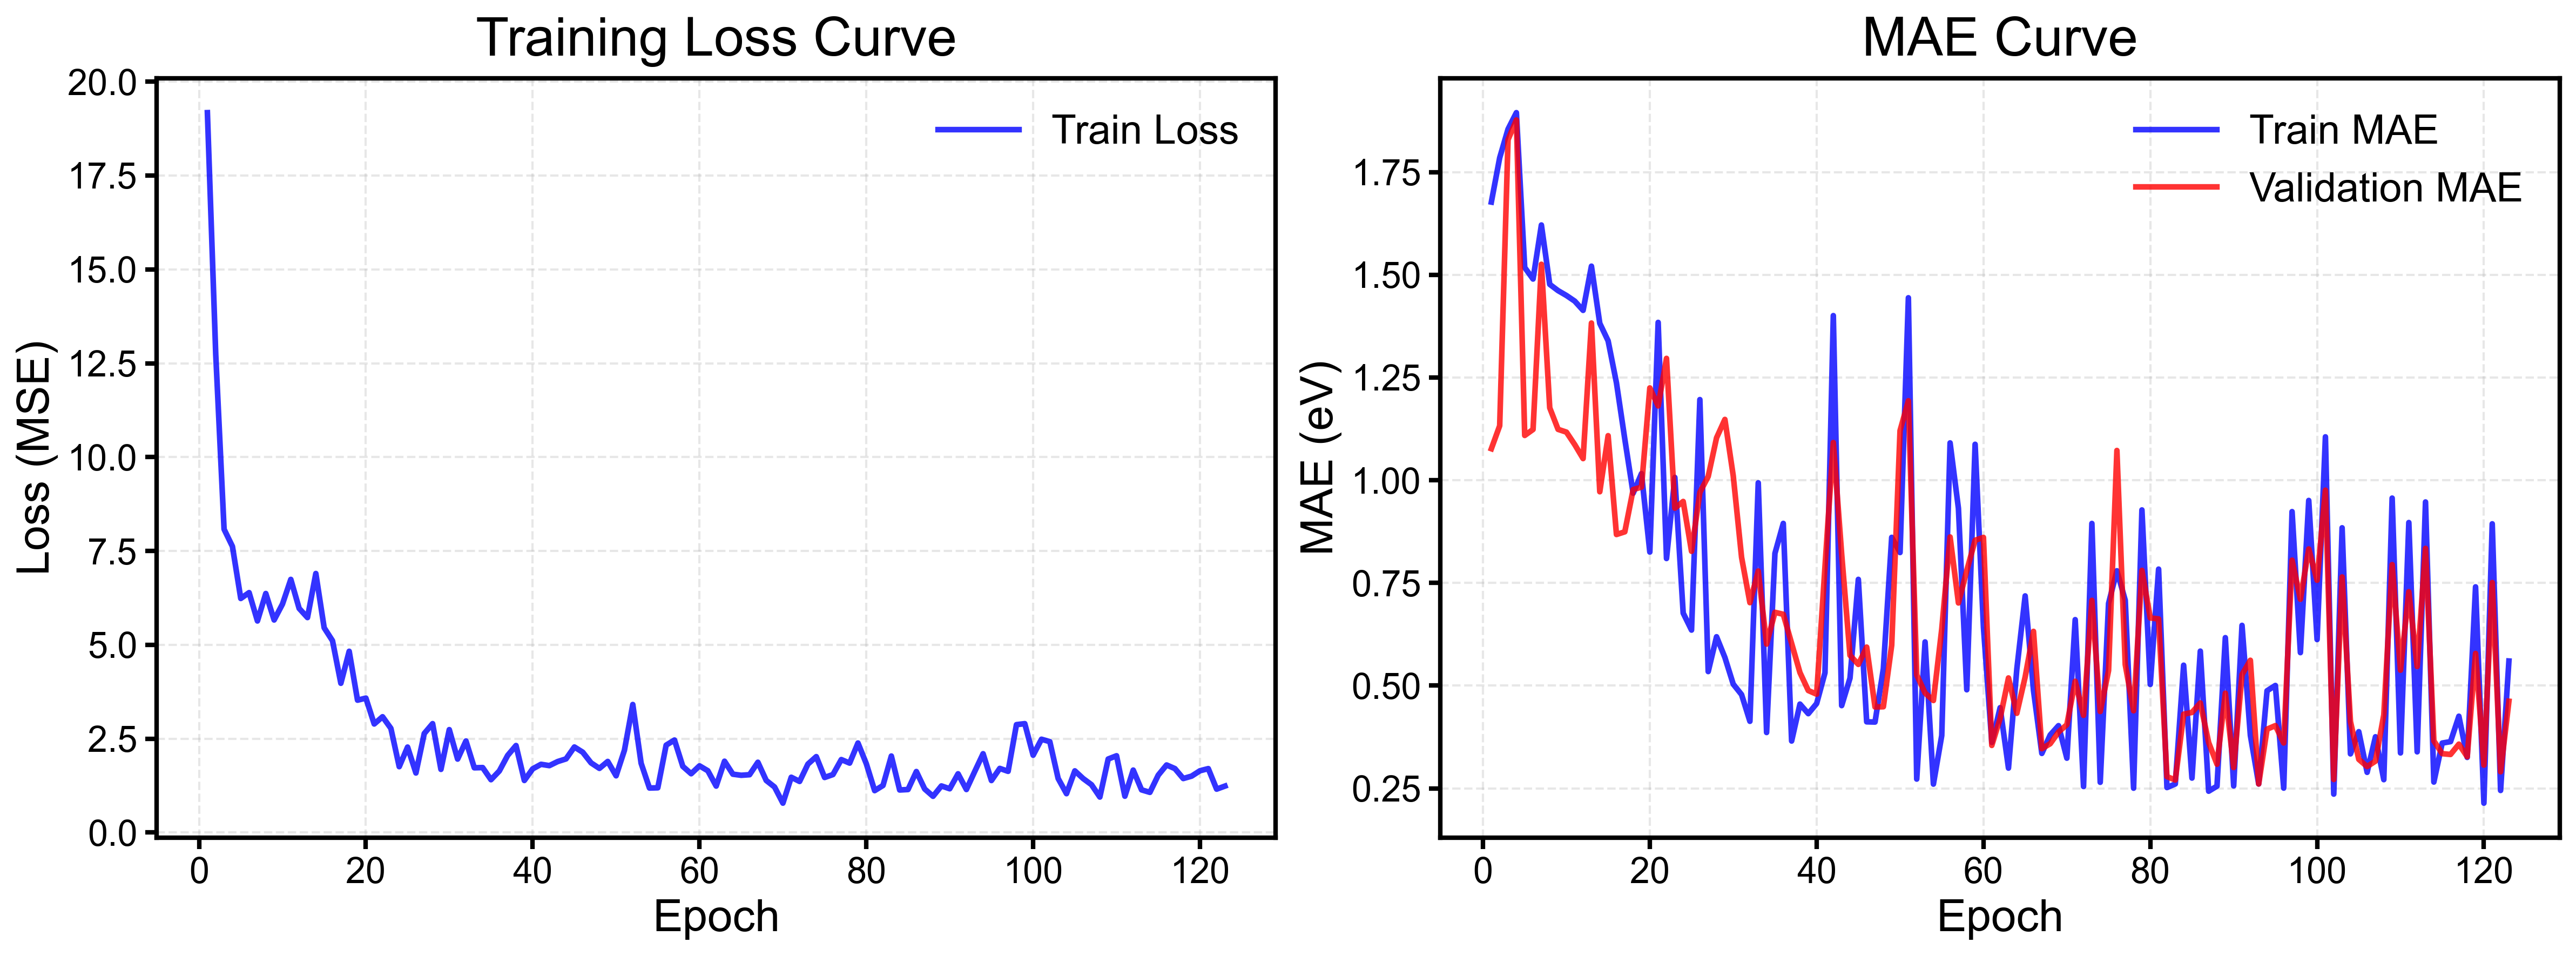


Training curves saved to: d:\Github\ML_elyte\models\training_curves.png

Training Summary:
  Total epochs: 123
  Best validation MAE: 0.2607 eV
  Final train loss: 1.2364
  Final train MAE: 0.5599 eV
  Final validation MAE: 0.4620 eV


In [12]:
# 绘制训练历史曲线(使用与散点图相似的样式)
plt.rcParams["font.family"] = "Arial"
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

epochs = range(1, len(history['train_loss']) + 1)

# 左图: Loss曲线
ax1 = axes[0]
ax1.plot(epochs, history['train_loss'], 'b-', linewidth=2.5, label='Train Loss', alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=20)
ax1.set_ylabel('Loss (MSE)', fontsize=20)
ax1.set_title('Training Loss Curve', fontsize=24, pad=10)
ax1.legend(frameon=False, fontsize=18, loc='upper right')
ax1.tick_params(axis='both', which='both', length=5, width=2, colors='black', labelsize=16)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_color('black')

# 右图: MAE曲线(训练集和验证集)
ax2 = axes[1]
ax2.plot(epochs, history['train_mae'], 'b-', linewidth=2.5, label='Train MAE', alpha=0.8)
ax2.plot(epochs, history['val_mae'], 'r-', linewidth=2.5, label='Validation MAE', alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=20)
ax2.set_ylabel('MAE (eV)', fontsize=20)
ax2.set_title('MAE Curve', fontsize=24, pad=10)
ax2.legend(frameon=False, fontsize=18, loc='upper right')
ax2.tick_params(axis='both', which='both', length=5, width=2, colors='black', labelsize=16)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=1)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_color('black')

plt.tight_layout()
fig.savefig(models_dir / 'training_curves.png', transparent=False, dpi=300)
plt.show()

print(f"\nTraining curves saved to: {models_dir / 'training_curves.png'}")
print(f"\nTraining Summary:")
print(f"  Total epochs: {len(history['train_loss'])}")
print(f"  Best validation MAE: {best_mae:.4f} eV")
print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
print(f"  Final train MAE: {history['train_mae'][-1]:.4f} eV")
print(f"  Final validation MAE: {history['val_mae'][-1]:.4f} eV")


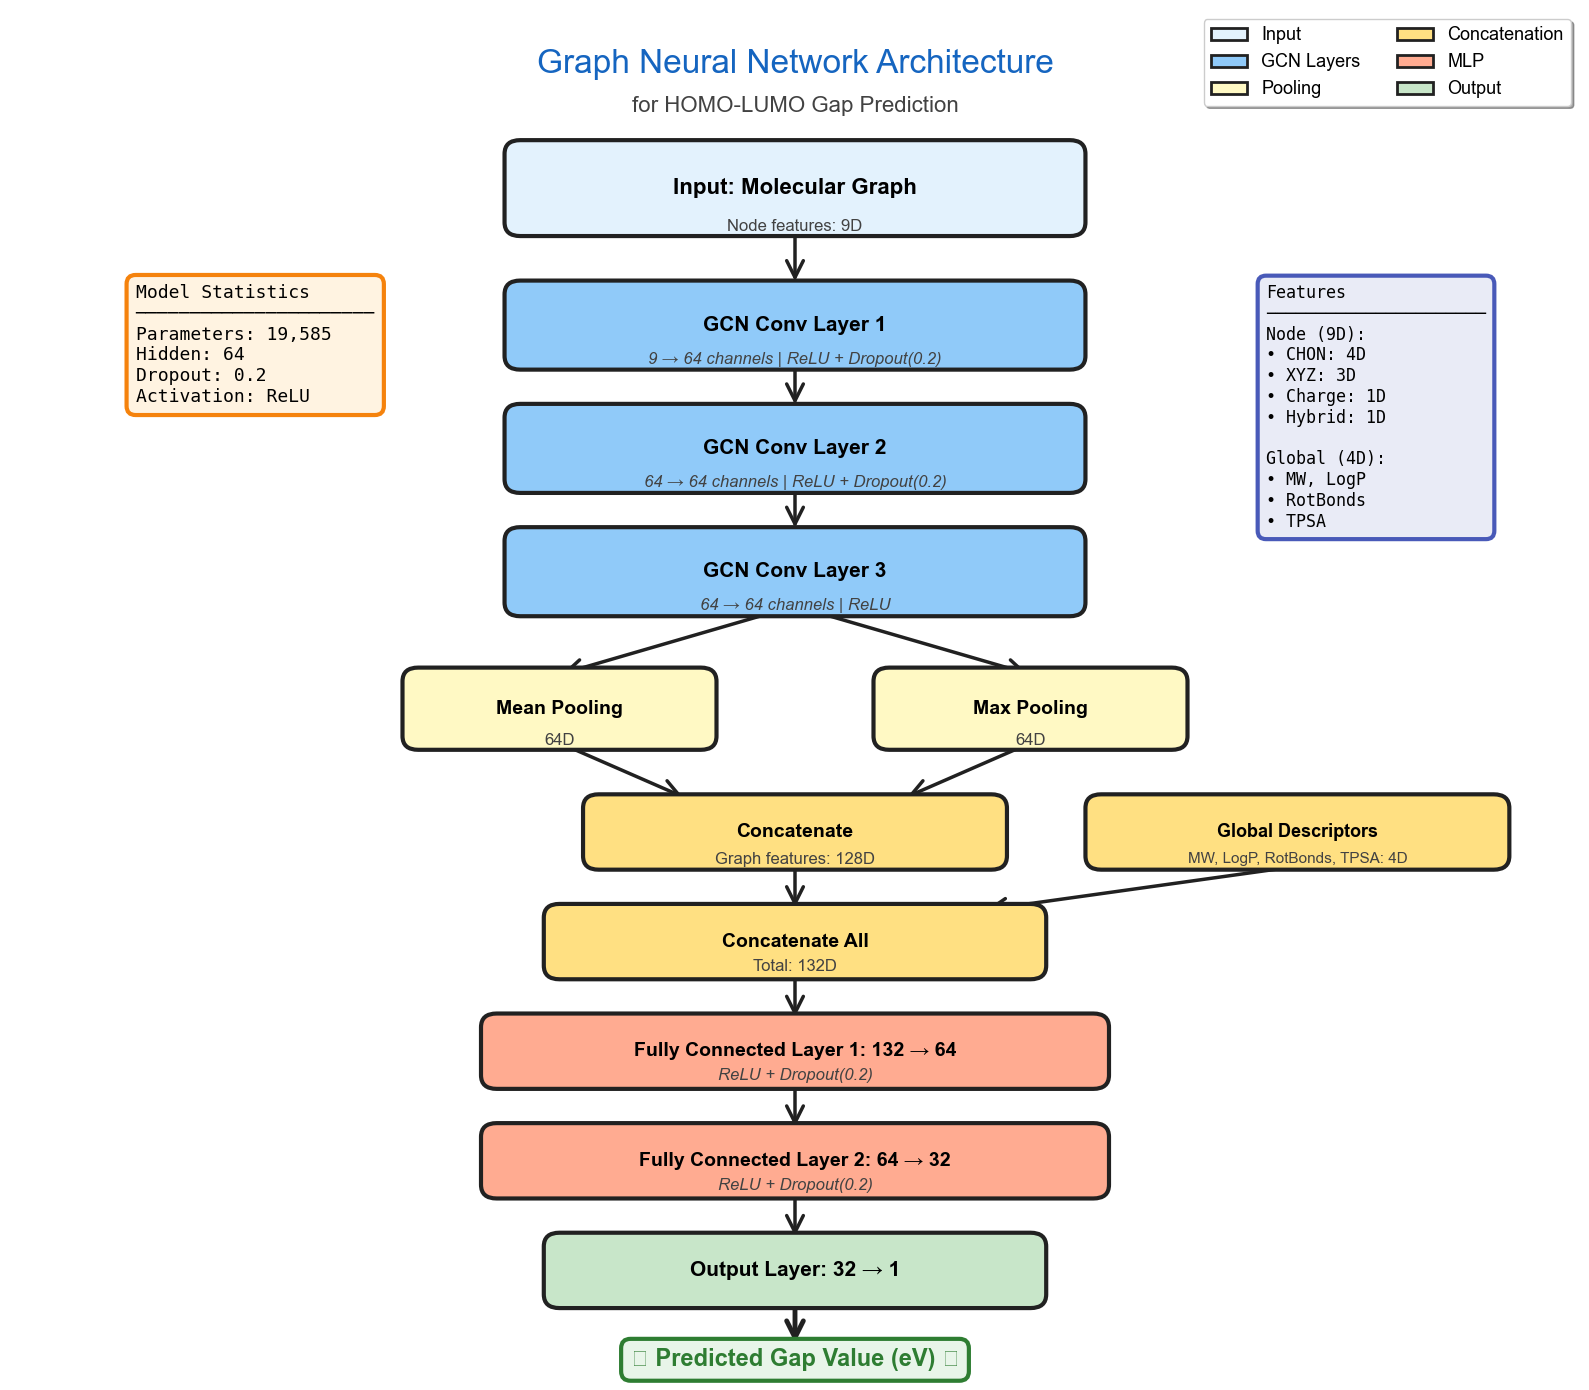

Model architecture diagram saved to: models/model_architecture.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# 创建图形，使用相对坐标系统
fig, ax = plt.subplots(figsize=(16, 14), dpi=100)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 配色方案
colors = {
    'input': '#E3F2FD',
    'gcn': '#90CAF9',
    'pool': '#FFF9C4',
    'concat': '#FFE082',
    'mlp': '#FFAB91',
    'output': '#C8E6C9',
}

def draw_box(ax, cx, cy, w, h, text, color, fontsize=14):
    """绘制居中的圆角矩形"""
    box = FancyBboxPatch((cx-w/2, cy-h/2), w, h, 
                         boxstyle="round,pad=0.01", 
                         edgecolor='#212121', facecolor=color, 
                         linewidth=3, zorder=2)
    ax.add_patch(box)
    ax.text(cx, cy, text, ha='center', va='center', 
           fontsize=fontsize, fontweight='bold', zorder=3)

def draw_arrow(ax, x1, y1, x2, y2, width=2.5):
    """绘制箭头"""
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=30, 
                           linewidth=width, color='#212121', zorder=1)
    ax.add_patch(arrow)

def add_text(ax, x, y, text, fontsize=13, style='normal', color='#424242'):
    """添加文本"""
    ax.text(x, y, text, ha='center', va='center', 
           fontsize=fontsize, style=style, color=color)

# ============ 标题 ============
add_text(ax, 0.5, 0.96, 'Graph Neural Network Architecture', 24, color='#1565C0')
add_text(ax, 0.5, 0.93, 'for HOMO-LUMO Gap Prediction', 16, color='#424242')

# ============ 输入层 ============
y = 0.87
draw_box(ax, 0.5, y, 0.35, 0.05, 'Input: Molecular Graph', colors['input'], 16)
add_text(ax, 0.5, y-0.028, 'Node features: 9D', 12)

# ============ GCN层 ============
y = 0.77
draw_arrow(ax, 0.5, 0.845, 0.5, y+0.03)
draw_box(ax, 0.5, y, 0.35, 0.045, 'GCN Conv Layer 1', colors['gcn'], 15)
add_text(ax, 0.5, y-0.025, '9 → 64 channels | ReLU + Dropout(0.2)', 12, 'italic')

y = 0.68
draw_arrow(ax, 0.5, 0.745, 0.5, y+0.03)
draw_box(ax, 0.5, y, 0.35, 0.045, 'GCN Conv Layer 2', colors['gcn'], 15)
add_text(ax, 0.5, y-0.025, '64 → 64 channels | ReLU + Dropout(0.2)', 12, 'italic')

y = 0.59
draw_arrow(ax, 0.5, 0.655, 0.5, y+0.03)
draw_box(ax, 0.5, y, 0.35, 0.045, 'GCN Conv Layer 3', colors['gcn'], 15)
add_text(ax, 0.5, y-0.025, '64 → 64 channels | ReLU', 12, 'italic')

# ============ 全局池化 ============
y = 0.49
draw_arrow(ax, 0.5, 0.565, 0.35, y+0.025)
draw_arrow(ax, 0.5, 0.565, 0.65, y+0.025)

draw_box(ax, 0.35, y, 0.18, 0.04, 'Mean Pooling', colors['pool'], 14)
add_text(ax, 0.35, y-0.023, '64D', 12)

draw_box(ax, 0.65, y, 0.18, 0.04, 'Max Pooling', colors['pool'], 14)
add_text(ax, 0.65, y-0.023, '64D', 12)

# ============ 特征拼接 ============
y = 0.40
draw_arrow(ax, 0.35, 0.465, 0.43, y+0.025)
draw_arrow(ax, 0.65, 0.465, 0.57, y+0.025)
draw_box(ax, 0.5, y, 0.25, 0.035, 'Concatenate', colors['concat'], 14)
add_text(ax, 0.5, y-0.02, 'Graph features: 128D', 12)

# 全局分子描述符
draw_box(ax, 0.82, y, 0.25, 0.035, 'Global Descriptors', colors['concat'], 13)
add_text(ax, 0.82, y-0.02, 'MW, LogP, RotBonds, TPSA: 4D', 11)

# 最终拼接
y = 0.32
draw_arrow(ax, 0.5, 0.375, 0.5, y+0.023)
draw_arrow(ax, 0.82, 0.375, 0.62, y+0.023)
draw_box(ax, 0.5, y, 0.3, 0.035, 'Concatenate All', colors['concat'], 14)
add_text(ax, 0.5, y-0.018, 'Total: 132D', 12)

# ============ MLP层 ============
y = 0.24
draw_arrow(ax, 0.5, 0.295, 0.5, y+0.023)
draw_box(ax, 0.5, y, 0.38, 0.035, 'Fully Connected Layer 1: 132 → 64', colors['mlp'], 14)
add_text(ax, 0.5, y-0.018, 'ReLU + Dropout(0.2)', 12, 'italic')

y = 0.16
draw_arrow(ax, 0.5, 0.215, 0.5, y+0.023)
draw_box(ax, 0.5, y, 0.38, 0.035, 'Fully Connected Layer 2: 64 → 32', colors['mlp'], 14)
add_text(ax, 0.5, y-0.018, 'ReLU + Dropout(0.2)', 12, 'italic')

# ============ 输出层 ============
y = 0.08
draw_arrow(ax, 0.5, 0.135, 0.5, y+0.023)
draw_box(ax, 0.5, y, 0.3, 0.035, 'Output Layer: 32 → 1', colors['output'], 15)

y = 0.01
draw_arrow(ax, 0.5, 0.055, 0.5, y+0.015, width=3.5)
ax.text(0.5, y, '★ Predicted Gap Value (eV) ★', 
       ha='center', fontsize=17, fontweight='bold', color='#2E7D32',
       bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', 
                edgecolor='#2E7D32', linewidth=3))

# ============ 图例 ============
legend_elements = [
    mpatches.Patch(facecolor=colors['input'], edgecolor='#212121', linewidth=2, label='Input'),
    mpatches.Patch(facecolor=colors['gcn'], edgecolor='#212121', linewidth=2, label='GCN Layers'),
    mpatches.Patch(facecolor=colors['pool'], edgecolor='#212121', linewidth=2, label='Pooling'),
    mpatches.Patch(facecolor=colors['concat'], edgecolor='#212121', linewidth=2, label='Concatenation'),
    mpatches.Patch(facecolor=colors['mlp'], edgecolor='#212121', linewidth=2, label='MLP'),
    mpatches.Patch(facecolor=colors['output'], edgecolor='#212121', linewidth=2, label='Output'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=13, 
         frameon=True, fancybox=True, shadow=True, ncol=2)

# ============ 信息框 ============
info_lines = [
    'Model Statistics',
    '─' * 22,
    f'Parameters: {sum(p.numel() for p in model.parameters()):,}',
    'Hidden: 64',
    'Dropout: 0.2',
    'Activation: ReLU',
]
info_text = '\n'.join(info_lines)

ax.text(0.08, 0.8, info_text, fontsize=13, verticalalignment='top',
       family='monospace',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0', 
                edgecolor='#F57C00', linewidth=3, alpha=0.95))

# ============ 特征详情框 ============
feature_lines = [
    'Features',
    '─' * 22,
    'Node (9D):',
    '• CHON: 4D',
    '• XYZ: 3D',
    '• Charge: 1D',
    '• Hybrid: 1D',
    '',
    'Global (4D):',
    '• MW, LogP',
    '• RotBonds',
    '• TPSA',
]
feature_text = '\n'.join(feature_lines)

ax.text(0.8, 0.8, feature_text, fontsize=12, verticalalignment='top',
       family='monospace',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8EAF6', 
                edgecolor='#3F51B5', linewidth=3, alpha=0.95))

plt.tight_layout()
fig.savefig(root / 'models' / 'model_architecture.png', dpi=300, 
           facecolor='white', edgecolor='none')
plt.show()

print("Model architecture diagram saved to: models/model_architecture.png")